In [1]:
!pwd

/mnt/c/Users/vvasileiou/Desktop/lncAPNet/Pilot_2_Prostate/notebooks/Post-hoc_Analysis


In [9]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import cdist
import umap
import matplotlib.pyplot as plt

In [2]:
# Load CSV into a DataFrame
df = pd.read_csv("../../../data/lncHUB2/umap_results_df.csv")
# Rename Unnamed: 0 -> gene
df = df.rename(columns={"Unnamed: 0": "gene"})
print(df.head())

          gene         x         y
0     A1BG-AS1  5.146417  1.982774
1      A2M-AS1  3.186969  2.305194
2    A2ML1-AS1 -4.484245  4.662058
3    A2ML1-AS2 -5.818414  4.214316
4  AADACL2-AS1 -4.124925  5.310025


In [3]:
import numpy as np
from scipy.spatial.distance import cdist

# --- Gene sets ---
known_genes = [
    "PCGEM1",
    "PCAT1",
    "PCAT6",
    "PCAT7",
    "PCAT18",
    "PCA3",
    "PCAT14",
    "SCHLAP1",
    "ARLNC1",
    "DRAIC",
    "PRCAT38",
    "HULLK"
]

test_genes = ["PRC1-AS1", "LINC01088", "FRY-AS1", "HLA-DQB1-AS1", "LINC01082", "HCG11"]

# Function to compute avg nearest distance from gene to known genes
def avg_distance_to_set(gene_coords, target_coords):
    distances = cdist(gene_coords, target_coords, metric='euclidean')
    min_distances = np.min(distances, axis=1)
    return np.mean(min_distances)

# Precompute known set coordinates
known_coords = df[df['gene'].isin(known_genes)][['x','y']].values
all_coords = df[['x','y']].values

# Permutation test parameters
n_permutations = 1000
np.random.seed(42)

results = []

for gene in test_genes:
    # Get coordinates for this gene
    gene_coords = df[df['gene'] == gene][['x','y']].values
    if gene_coords.shape[0] == 0:
        print(f"⚠️ No coordinates found for {gene}, skipping.")
        continue

    # Observed distance
    observed_distance = avg_distance_to_set(gene_coords, known_coords)

    # Permutation test
    permuted_distances = []
    n_points = gene_coords.shape[0]

    for _ in range(n_permutations):
        random_coords = all_coords[np.random.choice(all_coords.shape[0], n_points, replace=False)]
        permuted_distances.append(avg_distance_to_set(random_coords, known_coords))

    permuted_distances = np.array(permuted_distances)
    p_value = np.sum(permuted_distances <= observed_distance) / n_permutations

    # Save results
    results.append((gene, observed_distance, p_value))

# Print results
for gene, dist, pval in results:
    print(f"Observed avg distance of {gene} to known genes: {dist:.3f}")
    print(f"P-value for being close: {pval:.4f}\n")

Observed avg distance of PRC1-AS1 to known genes: 0.200
P-value for being close: 0.0210

Observed avg distance of LINC01088 to known genes: 0.769
P-value for being close: 0.2440

Observed avg distance of FRY-AS1 to known genes: 0.751
P-value for being close: 0.2150

Observed avg distance of HLA-DQB1-AS1 to known genes: 1.988
P-value for being close: 0.8010

Observed avg distance of LINC01082 to known genes: 0.284
P-value for being close: 0.0400

Observed avg distance of HCG11 to known genes: 1.101
P-value for being close: 0.3830



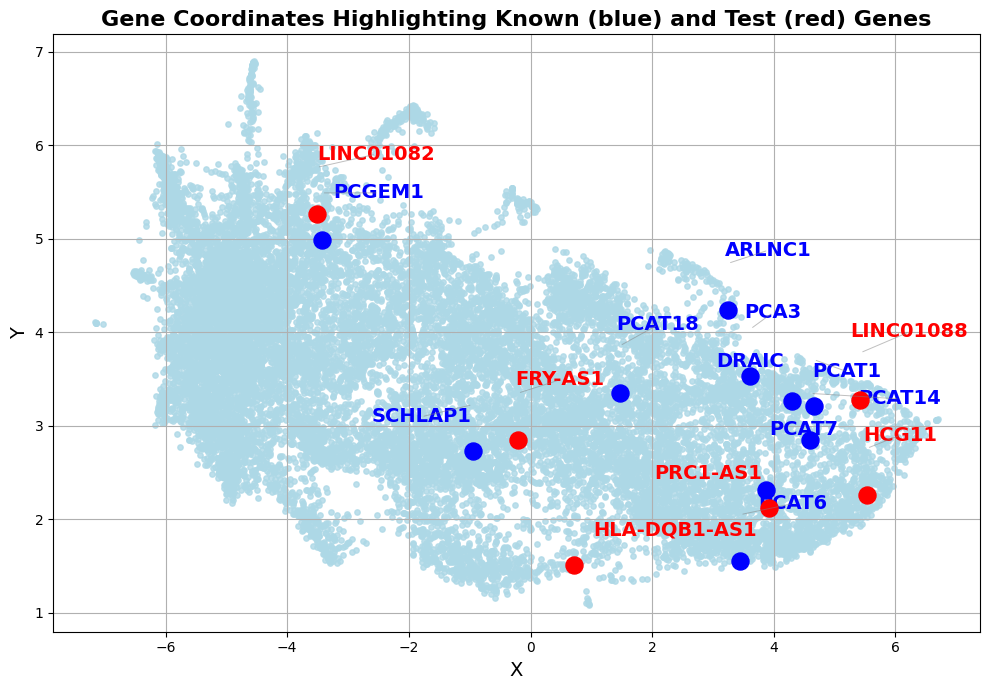

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text

# --- Prepare dataframe ---
df = df.rename(columns={"Unnamed: 0": "gene"})

# --- Gene sets ---
known_genes = [
    "PCGEM1",     # Promotes proliferation; androgen receptor (AR) regulated
    "PCAT1",      # Oncogenic; represses tumor suppressors like BRCA2
    "PCAT6",      # Promotes cell growth; AR signaling modulation
    "PCAT7",      # AR-associated; linked to metastasis
    "PCAT18",     # Overexpressed in metastatic adenocarcinoma
    "PCA3",       # Urinary biomarker; highly prostate-specific
    "PCAT14",     # Low expression linked to poor prognosis
    "SCHLAP1",    # Associated with aggressive disease and metastasis
    "ARLNC1",     # Stabilizes AR mRNA; AR-regulated
    "DRAIC",      # AR-regulated; inhibits cell invasion
    "PRCAT38",    # AR/FOXA1 regulated; shares enhancer with TMPRSS2
    "HULLK"       # Oncogenic role within LCK gene locus
]

test_genes = ["PRC1-AS1", "LINC01088", "FRY-AS1", "HLA-DQB1-AS1", "LINC01082", "HCG11"]

highlight_genes = known_genes + test_genes

# --- Basic scatter plot ---
plt.figure(figsize=(10, 7))
plt.scatter(df['x'], df['y'], color='lightblue', alpha=0.8, s=15)

texts = []

# --- Highlight known genes (blue) ---
for _, row in df.iterrows():
    if row['gene'] in known_genes:
        plt.scatter(row['x'], row['y'], color='blue', s=150, zorder=3)
        texts.append(
            plt.text(
                row['x'], row['y'] + 0.5, row['gene'],  # ↑ vertical offset for more distance
                fontsize=14, fontweight='bold', color='blue',
                ha='center', va='center'
            )
        )

# --- Highlight test genes (red) ---
for _, row in df.iterrows():
    if row['gene'] in test_genes:
        plt.scatter(row['x'], row['y'], color='red', s=150, zorder=3)
        texts.append(
            plt.text(
                row['x'], row['y'] + 0.5, row['gene'],  # ↑ same offset for consistency
                fontsize=14, fontweight='bold', color='red',
                ha='center', va='center'
            )
        )

# --- Automatically adjust text to avoid overlap ---
adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5, lw=0.7),
    expand_points=(4, 4),    # increased padding around points
    expand_text=(4, 4),      # increased padding around labels
    force_points=4,          # stronger push away from points
    force_text=4,            # stronger push between texts
    lim=800,                 # more iterations for optimal spacing
)

# --- Labels and formatting ---
plt.xlabel('X', fontsize=14)
plt.ylabel('Y', fontsize=14)
plt.title(
    'Gene Coordinates Highlighting Known (blue) and Test (red) Genes',
    fontsize=16, fontweight='bold'
)
plt.grid(True)
plt.tight_layout()

# --- Save and show ---
plt.savefig("../../figures/lncRNAs_umap.png", dpi=300, bbox_inches="tight")
plt.show()


In [8]:
# --------------------------
# Step 0: Load CSVs
# --------------------------
tissue_expr = pd.read_csv('../../../data/lncHUB2/tissue_expr.csv')
cell_line_expr = pd.read_csv('../../../data/lncHUB2/cell_line_expr.csv')

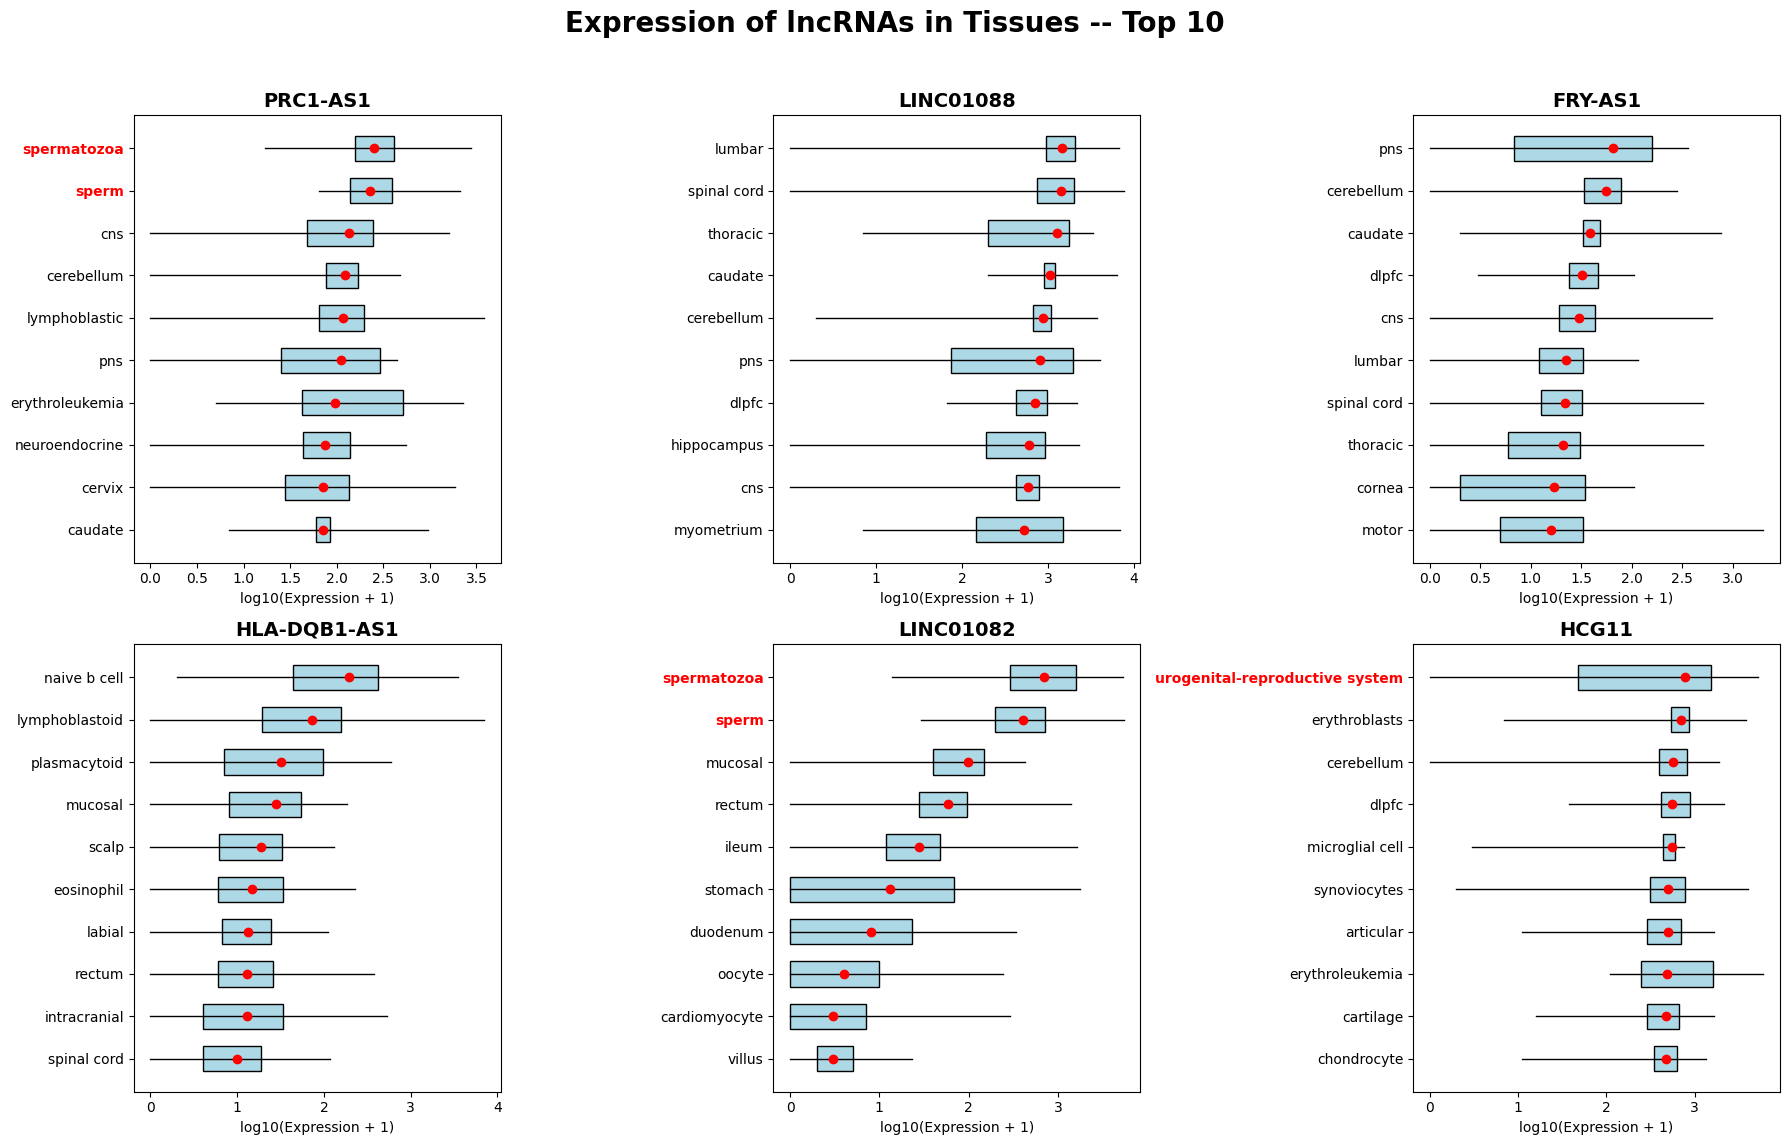

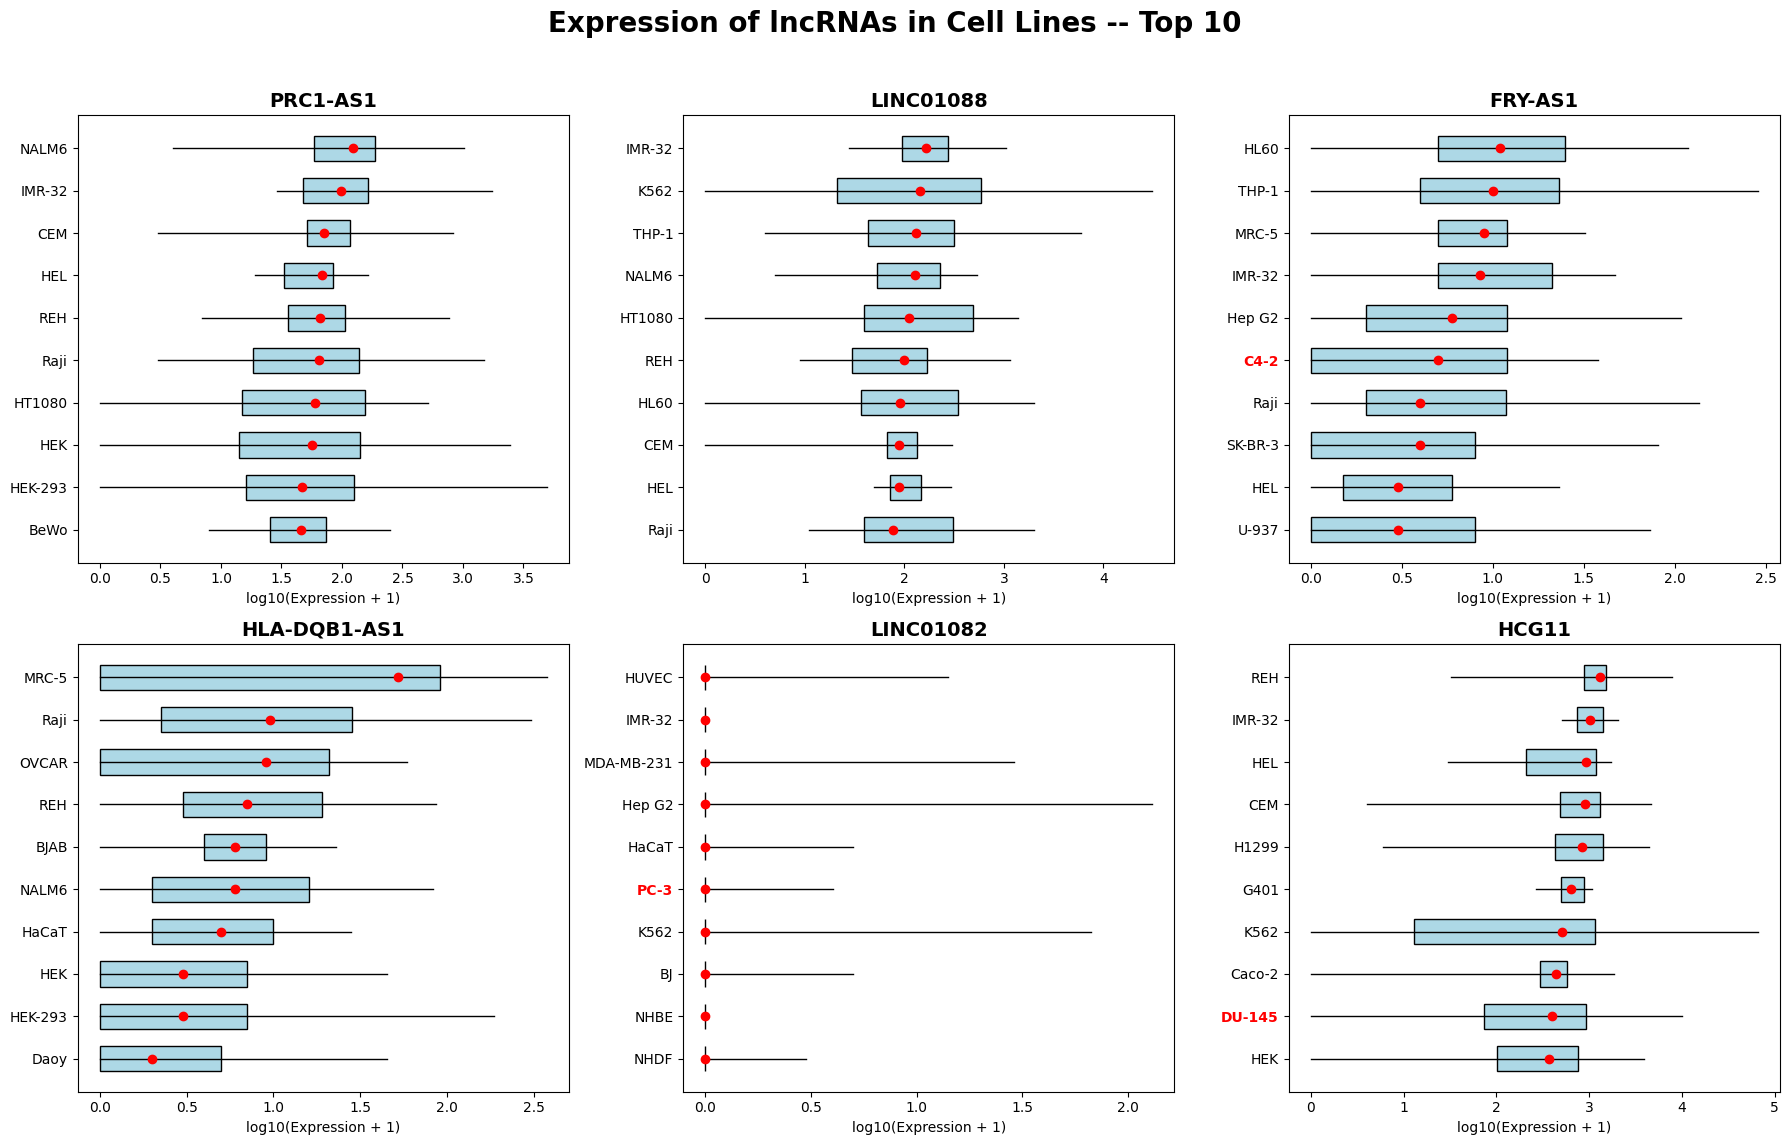

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --------------------------
# Step 1: Define genes to plot
# --------------------------
test_genes = ["PRC1-AS1", "LINC01088", "FRY-AS1", "HLA-DQB1-AS1", "LINC01082", "HCG11"]

# Tissue-specific highlights
highlight_tissues = ["spermatozoa", "sperm", "urogenital-reproductive system"]

# Cell line-specific highlights
highlight_cell_lines = ["C4-2", "DU-145", "LNCaP", "PC-3"]

# --------------------------
# Function to plot expression
# --------------------------
def plot_expression(df, title_prefix, save_path, highlight_items):
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    for idx, gene in enumerate(test_genes):
        ax = axes[idx]

        # Filter rows for the gene
        gene_stats = df[df['Unnamed: 0'] == gene].set_index('Unnamed: 1')
        gene_stats = gene_stats.drop(columns=['Unnamed: 0'])
        gene_stats = gene_stats.apply(pd.to_numeric)

        # Top 10 items by median
        top10 = gene_stats.loc[:, gene_stats.loc['50%'].sort_values(ascending=False).index[:10]]

        # Log-transform
        top10 = np.log10(top10 + 1)

        # Extract stats
        items = top10.columns
        min_vals = top10.loc['min']
        q1 = top10.loc['25%']
        median = top10.loc['50%']
        q3 = top10.loc['75%']
        max_vals = top10.loc['max']

        # Manual boxplot
        for i, (min_val, q1_val, med_val, q3_val, max_val) in enumerate(zip(min_vals, q1, median, q3, max_vals)):
            ax.plot([min_val, max_val], [i, i], color='black', linewidth=1)
            ax.add_patch(plt.Rectangle((q1_val, i-0.3), q3_val-q1_val, 0.6,
                                       facecolor='lightblue', edgecolor='black'))
            ax.plot(med_val, i, 'ro')

        # Customize y-axis
        ax.set_yticks(np.arange(len(items)))
        ax.set_yticklabels(items, fontsize=10)
        ax.invert_yaxis()
        ax.set_xlabel('log10(Expression + 1)')
        ax.set_title(f"{gene}", fontsize=14, fontweight='bold')

        # Highlight specific items in red and bold
        for tick_label in ax.get_yticklabels():
            if tick_label.get_text() in highlight_items:
                tick_label.set_color('red')
                tick_label.set_fontweight('bold')

    # Hide empty subplot
    for j in range(len(test_genes), len(axes)):
        axes[j].axis('off')

    # Main figure title
    fig.suptitle(f"{title_prefix} -- Top 10", fontsize=20, fontweight='bold', y=0.95)

    # Adjust layout to avoid overlap
    plt.tight_layout(rect=[0, 0, 1, 0.93])

    # Save figure
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


# --------------------------
# Step 2: Plot tissue expression
# --------------------------
plot_expression(tissue_expr,
                title_prefix="Expression of lncRNAs in Tissues",
                save_path="../../figures/lncRNAs_expression_Tissues_top10.png",
                highlight_items=highlight_tissues)

# --------------------------
# Step 3: Plot cell line expression
# --------------------------
plot_expression(cell_line_expr,
                title_prefix="Expression of lncRNAs in Cell Lines",
                save_path="../../figures/lncRNAs_expression_CellLines_top10.png",
                highlight_items=highlight_cell_lines)


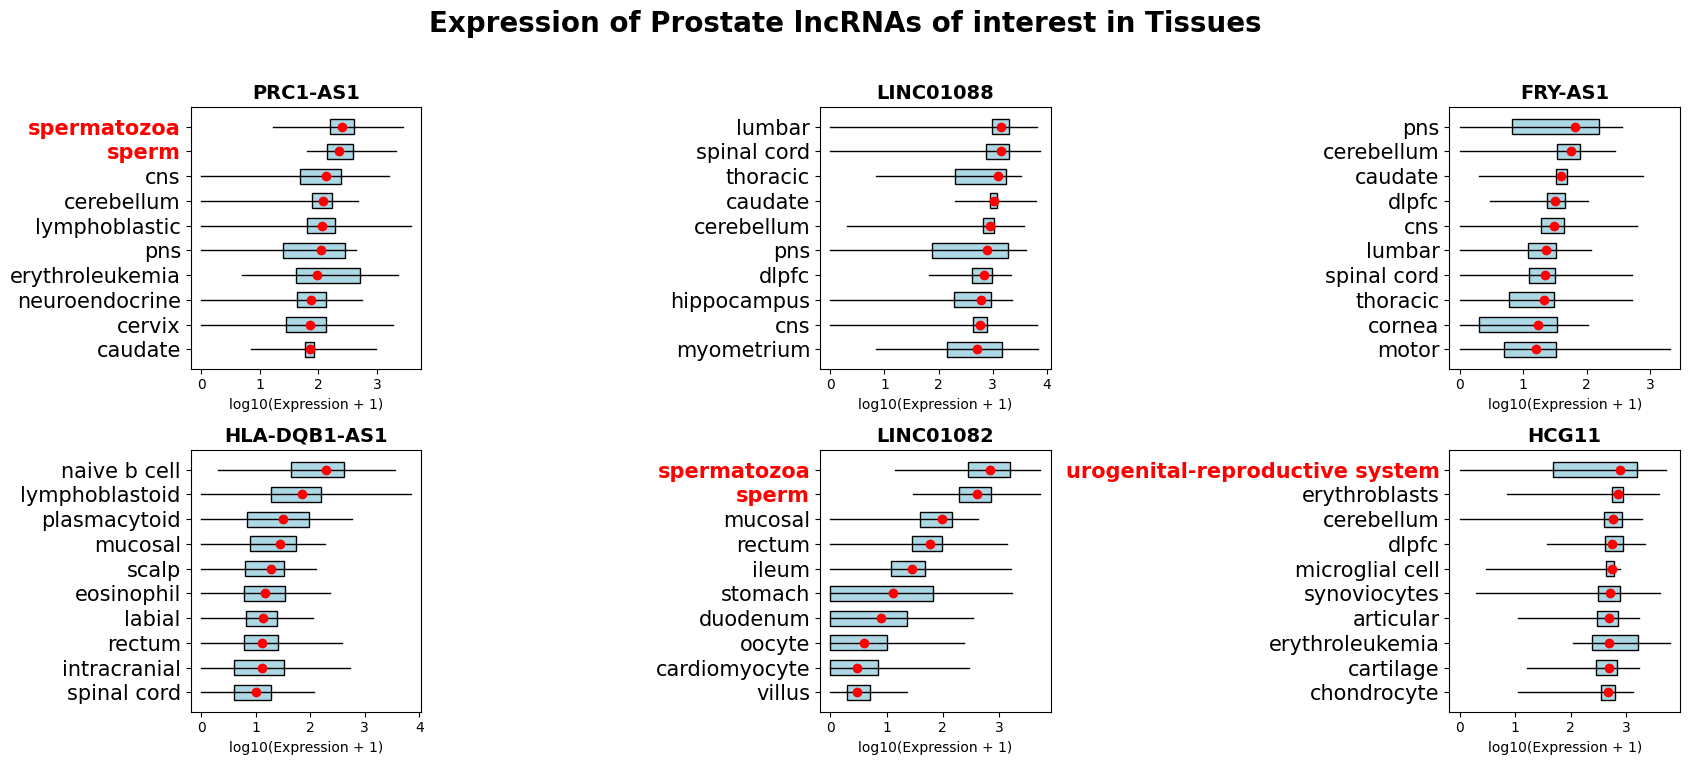

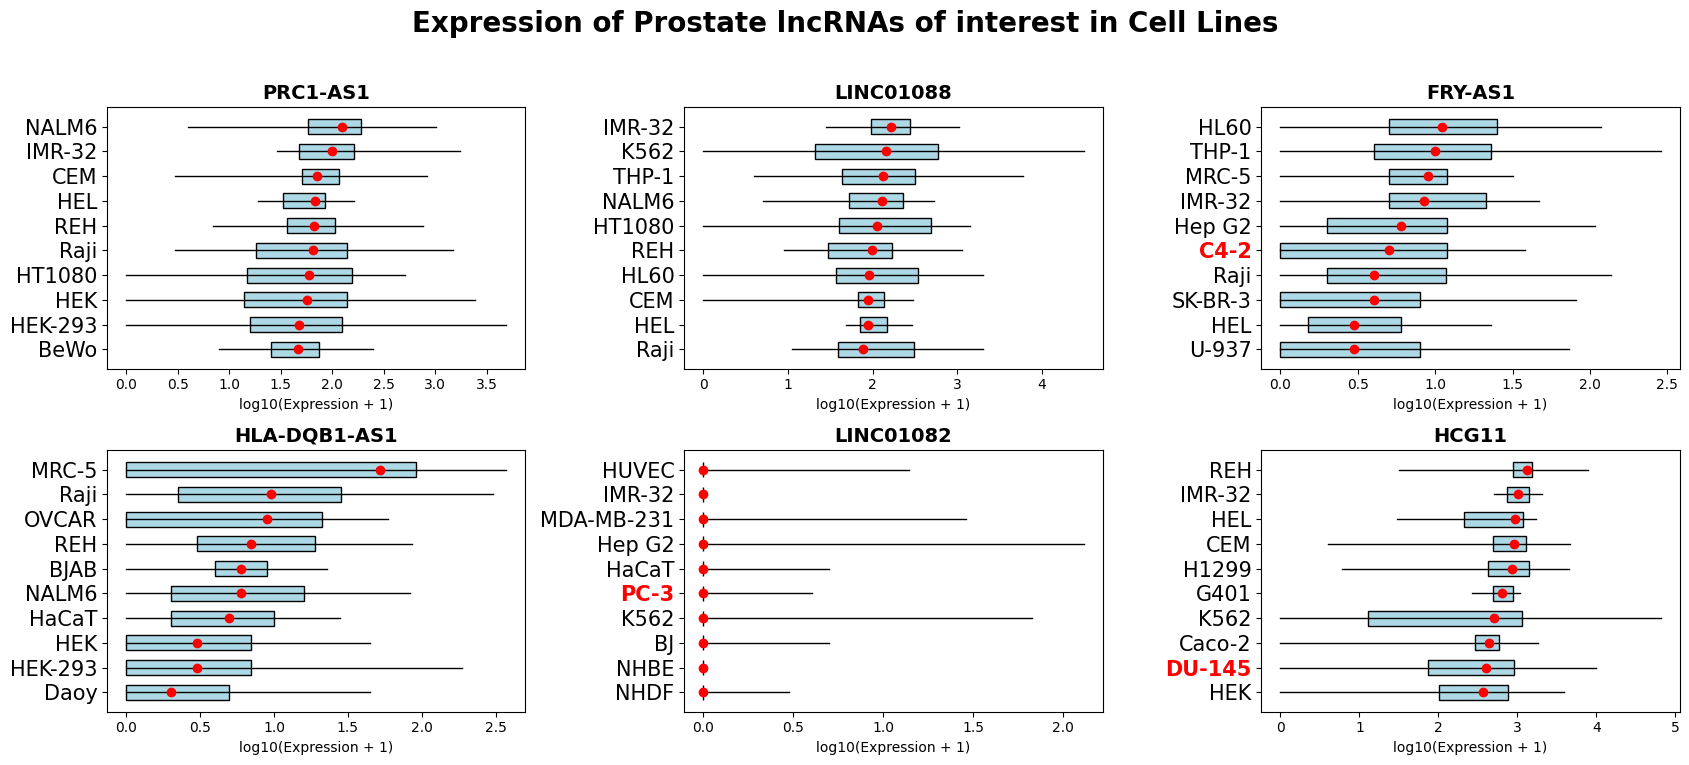

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --------------------------
# Step 1: Define genes to plot
# --------------------------
test_genes = ["PRC1-AS1", "LINC01088", "FRY-AS1", "HLA-DQB1-AS1", "LINC01082", "HCG11"]

# Tissue-specific highlights
highlight_tissues = ["spermatozoa", "sperm", "urogenital-reproductive system"]

# Cell line-specific highlights
highlight_cell_lines = ["C4-2", "DU-145", "LNCaP", "PC-3"]

# --------------------------
# Function to plot expression
# --------------------------
def plot_expression(df, title_prefix, save_path, highlight_items):
    fig, axes = plt.subplots(2, 3, figsize=(17, 8))
    axes = axes.flatten()

    for idx, gene in enumerate(test_genes):
        ax = axes[idx]

        # Filter rows for the gene
        gene_stats = df[df['Unnamed: 0'] == gene].set_index('Unnamed: 1')
        gene_stats = gene_stats.drop(columns=['Unnamed: 0'])
        gene_stats = gene_stats.apply(pd.to_numeric)

        # Top 10 items by median
        top10 = gene_stats.loc[:, gene_stats.loc['50%'].sort_values(ascending=False).index[:10]]

        # Log-transform
        top10 = np.log10(top10 + 1)

        # Extract stats
        items = top10.columns
        min_vals = top10.loc['min']
        q1 = top10.loc['25%']
        median = top10.loc['50%']
        q3 = top10.loc['75%']
        max_vals = top10.loc['max']

        # Manual boxplot
        for i, (min_val, q1_val, med_val, q3_val, max_val) in enumerate(zip(min_vals, q1, median, q3, max_vals)):
            ax.plot([min_val, max_val], [i, i], color='black', linewidth=1)
            ax.add_patch(plt.Rectangle((q1_val, i-0.3), q3_val-q1_val, 0.6,
                                       facecolor='lightblue', edgecolor='black'))
            ax.plot(med_val, i, 'ro')

        # Customize y-axis
        ax.set_yticks(np.arange(len(items)))
        ax.set_yticklabels(items, fontsize=15)
        ax.invert_yaxis()
        ax.set_xlabel('log10(Expression + 1)')
        ax.set_title(f"{gene}", fontsize=14, fontweight='bold')

        # Highlight specific items in red and bold
        for tick_label in ax.get_yticklabels():
            if tick_label.get_text() in highlight_items:
                tick_label.set_color('red')
                tick_label.set_fontweight('bold')

    # Hide empty subplot
    for j in range(len(test_genes), len(axes)):
        axes[j].axis('off')

    # Main figure title
    fig.suptitle(f"{title_prefix}", fontsize=20, fontweight='bold', y=0.95)

    # Adjust layout to avoid overlap
    plt.tight_layout(rect=[0, 0, 1, 0.93])

    # Save figure
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


# --------------------------
# Step 2: Plot tissue expression
# --------------------------
plot_expression(tissue_expr,
                title_prefix="Expression of Prostate lncRNAs of interest in Tissues",
                save_path="../../figures/lncRNAs_expression_Tissues_top10.png",
                highlight_items=highlight_tissues)

# --------------------------
# Step 3: Plot cell line expression
# --------------------------
plot_expression(cell_line_expr,
                title_prefix="Expression of Prostate lncRNAs of interest in Cell Lines",
                save_path="../../figures/lncRNAs_expression_CellLines_top10.png",
                highlight_items=highlight_cell_lines)
